### Data Cleaning

In [8]:
# Why Missing Values Matter in Data Science
# Real-world data kabhi bhi perfect nahi hota
# Missing values ki wajah se:
#   - ML models crash kar sakte hain
#   - Bias aa sakta hai
#   - Wrong insights milte hain

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Age": [25, None, 30, 28, None],
    "Salary": [50000, 60000, None, 58000, 62000],
    "City": ["Delhi", "Mumbai", None, "Delhi", "Mumbai"]
})

df.isnull().sum()


# Always analyze missingness before imputation


Age       2
Salary    1
City      1
dtype: int64

In [10]:
# Imputation Strategies (MOST IMPORTANT)

# Mean Imputation (Numerical)
#   - Jab data normally distributed ho

df["Age"].fillna(df["Age"].mean(), inplace=True)

# Outliers se mean distort ho jata hai
# Use When: 
#   - No strong outliers
#   - Quick baseline model

C:\Users\govin\AppData\Local\Temp\ipykernel_15584\2317941676.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)


In [11]:
# Median Imputation (Numerical – MOST USED)
# Jab outliers present ho

df["Salary"].fillna(df["Salary"].median(), inplace=True)

# Use when:
#   - Skewed data

C:\Users\govin\AppData\Local\Temp\ipykernel_15584\3894993598.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Salary"].fillna(df["Salary"].median(), inplace=True)


In [12]:
# Mode Imputation (Categorical)
# Categorical columns ke liye

df["City"].fillna(df["City"].mode()[0], inplace=True)

# Use when:
# Categorical features
# Low missing percentage

C:\Users\govin\AppData\Local\Temp\ipykernel_15584\132799198.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["City"].fillna(df["City"].mode()[0], inplace=True)


In [13]:
# Constant / Placeholder Value
# Jab missing ka meaning itself important ho

df["City"].fillna("Unknown", inplace=True)

# Use when:
#   - “Not Provided” is meaningful
#   - Business logic required

In [14]:
# Forward Fill / Backward Fill (Time Series)
# Mostly time-based data me

df.fillna(method="ffill", inplace=True)
# OR
df.fillna(method="bfill", inplace=True)

# Use when:
#   - Stock prices
#   - Sensor data
#   - Sequential records

C:\Users\govin\AppData\Local\Temp\ipykernel_15584\979649012.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)
C:\Users\govin\AppData\Local\Temp\ipykernel_15584\979649012.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="bfill", inplace=True)


In [ ]:
# KNN Imputation
# Similar rows se missing value fill karta hai

from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=3)
df_numeric = df.select_dtypes(include="number")
df[df_numeric.columns] = imputer.fit_transform(df_numeric)

# Better than mean/median
# Slow on large data

# Use when:
#   - Small to medium datasets
#   - Feature relationships important


In [ ]:
# Model-Based Imputation (High-Level)
# ML model use karke missing predict karna

# Examples:
#   - Regression Imputation
#   - Random Forest Imputation

# Use when:
#   - High missing %
#   - High-stakes prediction models

In [15]:
# Handling Duplicates

# What are Duplicates?
# Duplicates matlab same record ka multiple baar aana.

# Real-world examples:
#  - Same customer entered twice
#  - Same transaction logged multiple times
#  - Data merge / join ke baad duplicate rows
#Duplicates = biased analysis + wrong ML models

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "CustomerID": [101, 102, 103, 103, 104],
    "Name": ["Amit", "Riya", "John", "John", "Sara"],
    "City": ["Delhi", "Mumbai", "Delhi", "Delhi", "Pune"]
})

df.duplicated()

# True = duplicate row

0    False
1    False
2    False
3     True
4    False
dtype: bool

In [17]:
# Count duplicates

df.duplicated().sum()

# “Always check duplicates before modeling.”


np.int64(1)

In [ ]:
# Remove Exact Duplicate Rows

df.drop_duplicates(inplace=True)


In [18]:
# Keep First / Last Duplicate

df.drop_duplicates(keep="first")   # default
df.drop_duplicates(keep="last")


,CustomerID,Name,City
0,101,Amit,Delhi
1,102,Riya,Mumbai
3,103,John,Delhi
4,104,Sara,Pune


In [ ]:
# Subset-Based Duplicates (VERY IMPORTANT)
# Sometimes entire row same nahi hota, but business key same hota hai.
# Example: Same CustomerID twice

df.drop_duplicates(subset=["CustomerID"], inplace=True)

# Use when:
#   - Customer-level data
#   - Product-level data

In [ ]:
# Find Which Rows are Duplicate

df[df.duplicated(subset=["CustomerID"], keep=False)]

# Helps in investigation, not blind deletion


In [ ]:
# Duplicates After Merging (REAL-WORLD SCENARIO)

df_merged = pd.merge(df1, df2, on="CustomerID", how="left")
df_merged.duplicated().sum()


# Always check duplicates after joins

### Matplotlib

In [19]:
# Matplotlib = base visualization library in Python.
# EDA (Exploratory Data Analysis) me sabse pehle isi se kaam shuru hota hai.

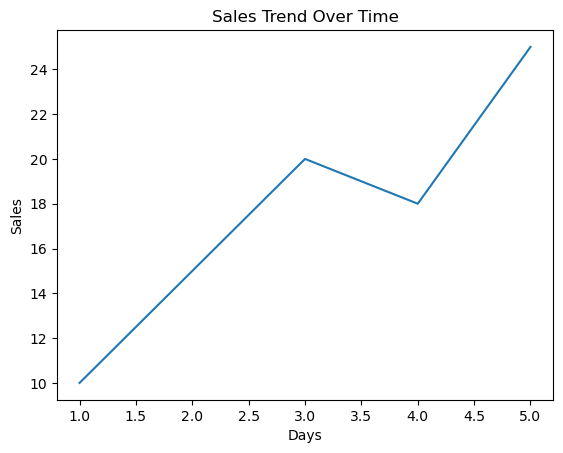

In [ ]:
# Line Plot (Trend Analysis)
#   - Jab data continuous ya time-based ho

# Use Case
#   - Sales vs Date
#   - Temperature vs Time
#   - Stock prices

import matplotlib.pyplot as plt

x = [1, 2, 3, 4, 5]
y = [10, 15, 20, 18, 25]

plt.plot(x, y)
plt.xlabel("Days")
plt.ylabel("Sales")
plt.title("Sales Trend Over Time")
plt.show()

# What Line Plot Tells You
#   - Increasing / decreasing trend
#   - Seasonality
#   - Sudden spikes or drops
# Data Science Insight:
#   - Trend samajhna forecasting & business decisions ke liye critical hai.


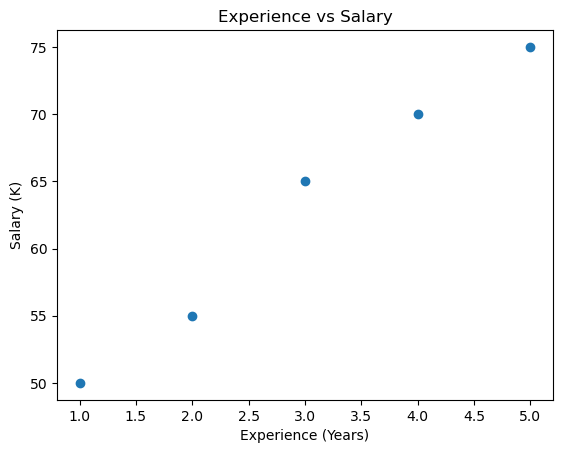

In [22]:
# Scatter Plot (Relationship Analysis)
#   - Jab dekhna ho 2 numerical variables ka relation

# Use Case:
#   - Height vs Weight
#   - Salary vs Experience
#   - Age vs Spending score

x = [1, 2, 3, 4, 5]
y = [50, 55, 65, 70, 75]

plt.scatter(x, y)
plt.xlabel("Experience (Years)")
plt.ylabel("Salary (K)")
plt.title("Experience vs Salary")
plt.show()

# What Scatter Plot Tells You
#   - Positive correlation
#   - Negative correlation
#   - No relationship
#   - Outliers detection
# Very important for feature selection

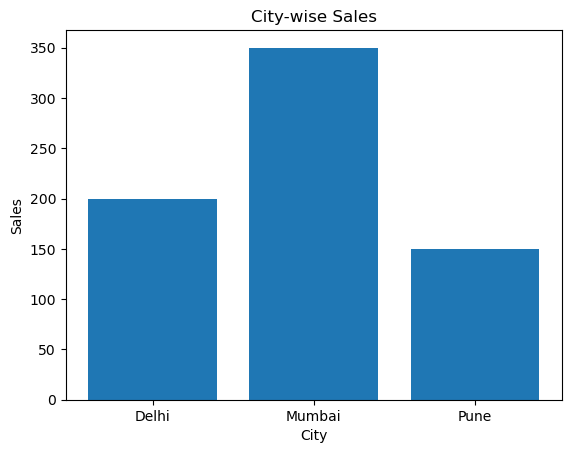

In [23]:
# Bar Chart (Categorical Comparison)
# Jab categories compare karni ho

# Use Cases:
#   - Sales by City
#   - Count of customers per segment
#   - Product-wise revenue

import matplotlib.pyplot as plt

cities = ["Delhi", "Mumbai", "Pune"]
sales = [200, 350, 150]

plt.bar(cities, sales)
plt.xlabel("City")
plt.ylabel("Sales")
plt.title("City-wise Sales")
plt.show()

# What Bar Chart Tells You
#   - Highest / lowest category
#   - Category imbalance
#   - Business performance comparison
# Feature engineering & business insights

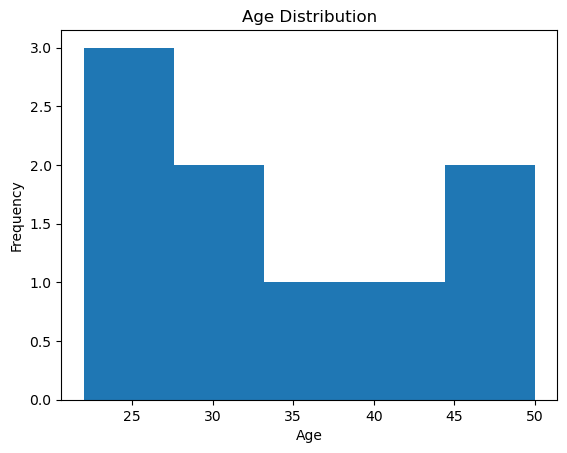

In [24]:
# Histogram (Numerical Distribution)
#   - Jab numerical data ka spread dekhna ho

# Use Cases:
#   - Age distribution
#   - Salary distribution
#   - Transaction amount spread

ages = [22, 25, 27, 30, 32, 35, 40, 45, 50]

plt.hist(ages, bins=5)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Age Distribution")
plt.show()

# What Histogram Tells You
#   - Skewness (left/right)
#   - Normal vs non-normal distribution
#   - Outliers presence
# Scaling & model selection ke liye important

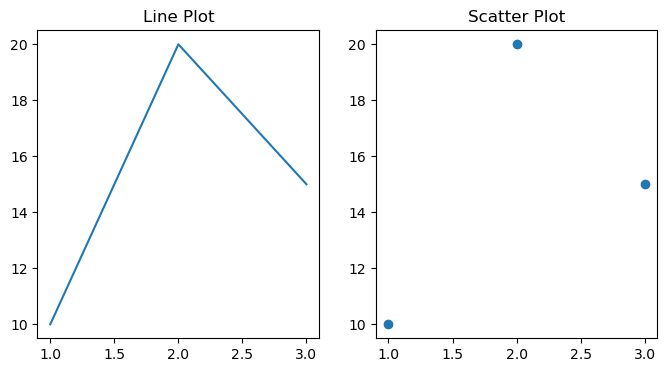

In [25]:
# Subplots and figures
# Clean, professional, scalable

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].plot([1, 2, 3], [10, 20, 15])
axes[0].set_title("Line Plot")

axes[1].scatter([1, 2, 3], [10, 20, 15])
axes[1].set_title("Scatter Plot")

plt.show()


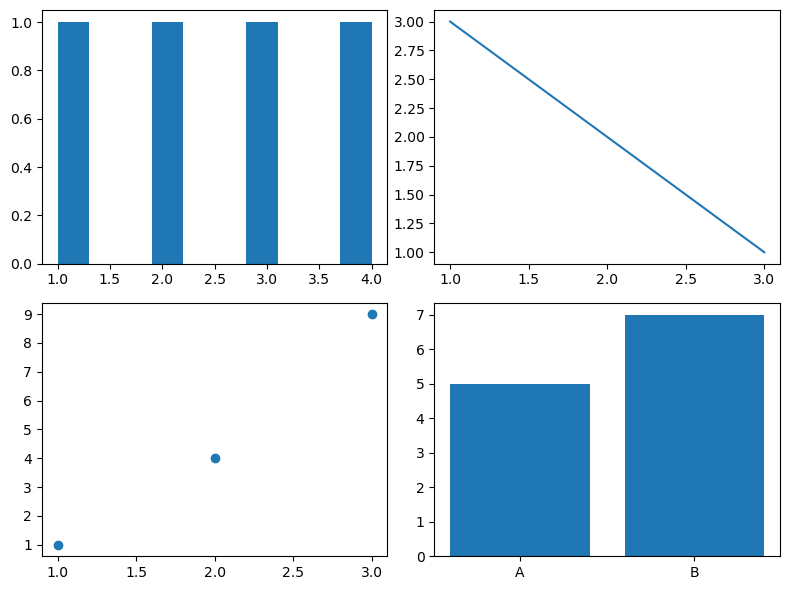

In [27]:
# 2D Axes Indexing

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0, 0].hist([1, 2, 3, 4])
axes[0, 1].plot([1, 2, 3], [3, 2, 1])
axes[1, 0].scatter([1, 2, 3], [1, 4, 9])
axes[1, 1].bar(["A", "B"], [5, 7])

plt.tight_layout()
plt.show()


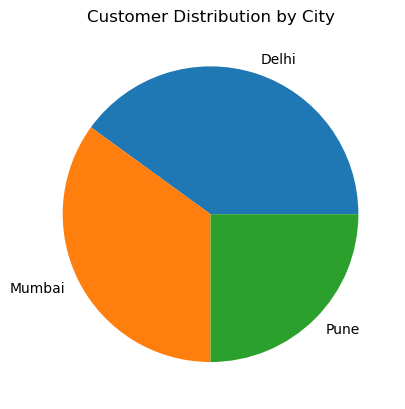

In [28]:
# Basic Pie Chart
import matplotlib.pyplot as plt

labels = ["Delhi", "Mumbai", "Pune"]
sizes = [40, 35, 25]

plt.pie(sizes, labels=labels)
plt.title("Customer Distribution by City")
plt.show()


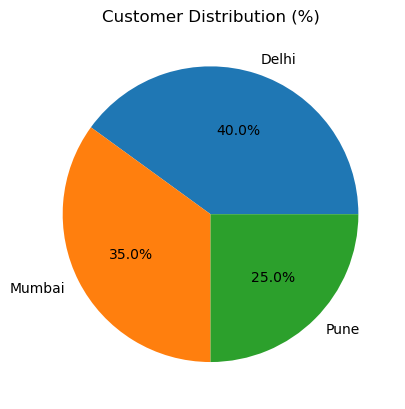

In [29]:
# Show Percentages (MOST USED)

plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Customer Distribution (%)")
plt.show()

# %1.1f%% → one decimal percentage

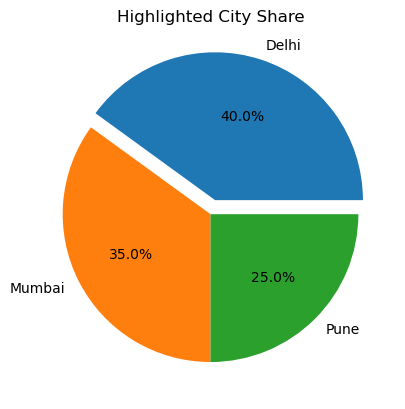

In [ ]:
# Highlight a Slice (Explode)

explode = [0.1, 0, 0]

plt.pie(sizes, labels=labels, autopct="%1.1f%%", explode=explode)
plt.title("Highlighted City Share")
plt.show()

# Use sparingly (only key category)

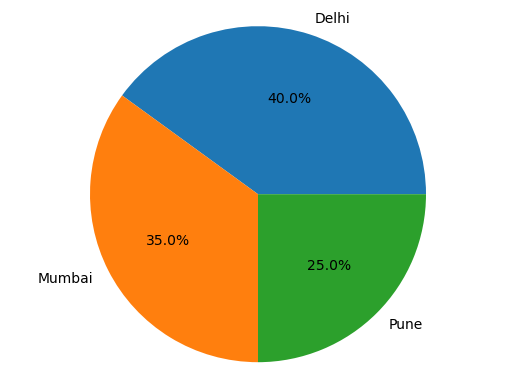

In [31]:
# Better Look (Equal Aspect Ratio)

plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.axis("equal")
plt.show()

# Circle ko ellipse banne se bachata hai


### Seaborn

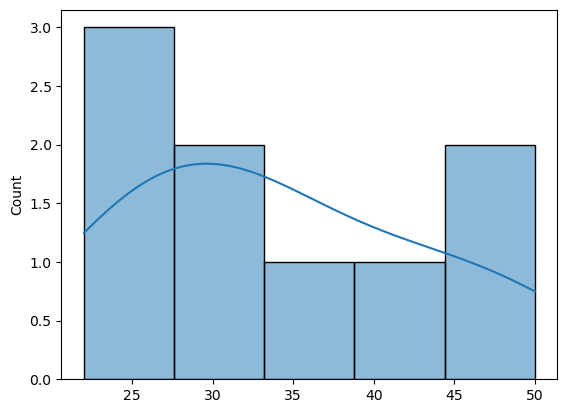

In [ ]:
##  Statistical plots (distplot, boxplot, violinplot)
# Distplot (Distribution Plot)
# Shows how data is distributed

# Note -> Important 
# (distplot) is deprecated, but interview me concept valid hai.
# Modern replacement:
# histplot()
# kdeplot()

import seaborn as sns
import matplotlib.pyplot as plt

data = [22, 25, 27, 30, 32, 35, 40, 45, 50]

sns.histplot(data, kde=True)
plt.show()

# Combines:
#   - Histogram
#   - KDE(Smooth curve)


# What Distplot Tells You
#   - Normal vs skewed data
#   - Spread of values
#   - Need for log / scaling


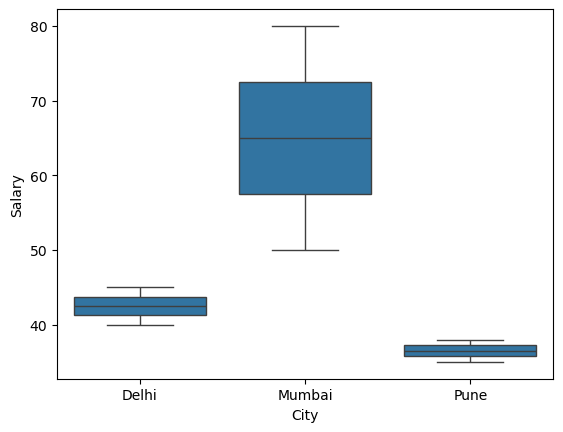

In [34]:
# Boxplot (Outlier Detection KING) 
# Shows 5-number summary
#   - Min, Q1, Median, Q3, Max
#   - Outliers clearly

import pandas as pd

df = pd.DataFrame({
    "City": ["Delhi", "Delhi", "Mumbai", "Mumbai", "Pune", "Pune"],
    "Salary": [40, 45, 50, 80, 35, 38]
})

sns.boxplot(x="City", y="Salary", data=df)
plt.show()


# What Boxplot Tells You
#   - Outliers
#   - Median comparison
#   - Spread across categories


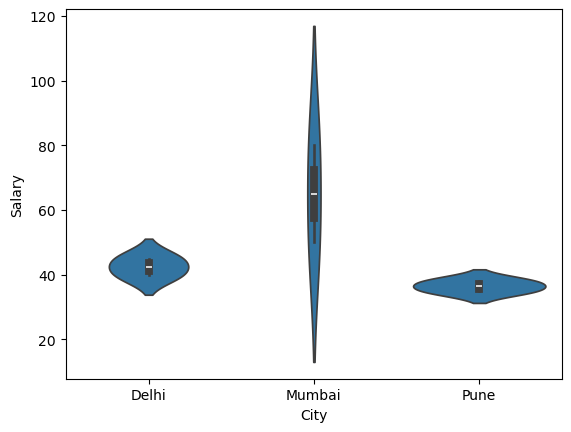

In [35]:
# Violin Plot (Advanced + Powerful)
#  Boxplot + KDE (density)

sns.violinplot(x="City", y="Salary", data=df)
plt.show()

# Why Violin Plot?
#   - Shows distribution shape
#   - Shows density
#   - Better than boxplot when data is large

# Use when:
#   - You want deeper insight than boxplot

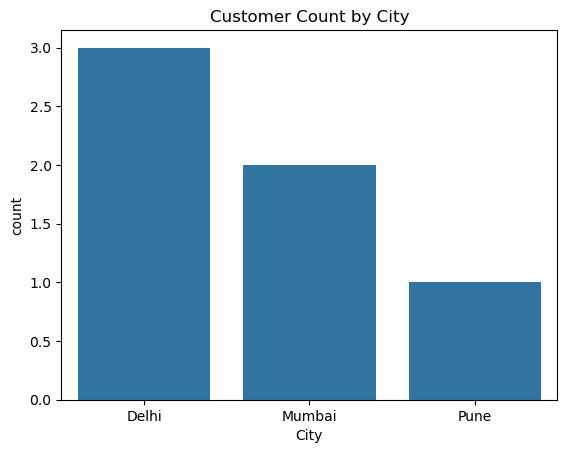

In [36]:
## Categorical plots (countplot, barplot)

# Countplot (Frequency Check)
#   - Automatically counts values
#   - Most used categorical plot in EDA

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "City": ["Delhi", "Mumbai", "Delhi", "Pune", "Mumbai", "Delhi"]
})

sns.countplot(x="City", data=df)
plt.title("Customer Count by City")
plt.show()

# What Countplot Tells You
#   - Category imbalance
#   - Dominant class
#   - Sampling bias (important for ML)

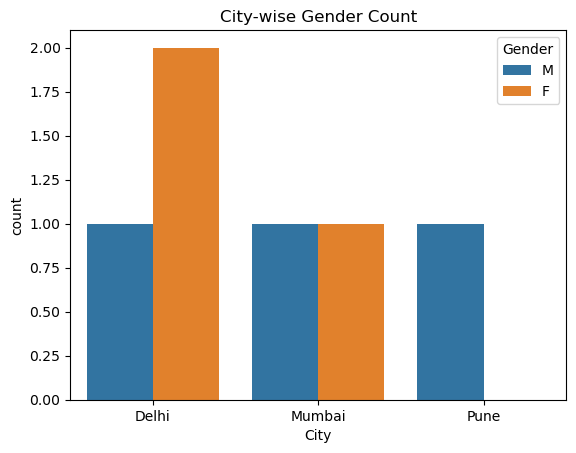

In [37]:
# With hue (Category within Category)

df["Gender"] = ["M", "F", "F", "M", "M", "F"]

sns.countplot(x="City", hue="Gender", data=df)
plt.title("City-wise Gender Count")
plt.show()


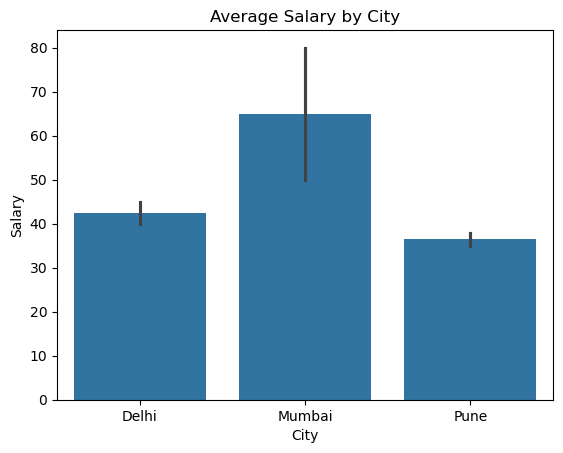

In [38]:
# Barplot (Category Comparison)
#   - Shows mean of a numerical variable for each category

df = pd.DataFrame({
    "City": ["Delhi", "Delhi", "Mumbai", "Mumbai", "Pune", "Pune"],
    "Salary": [40, 45, 50, 80, 35, 38]
})

sns.barplot(x="City", y="Salary", data=df)
plt.title("Average Salary by City")
plt.show()

# What Barplot Tells You
#   - Category-wise comparison
#   - Which group performs better
#   - Business insights (avg sales, avg salary)

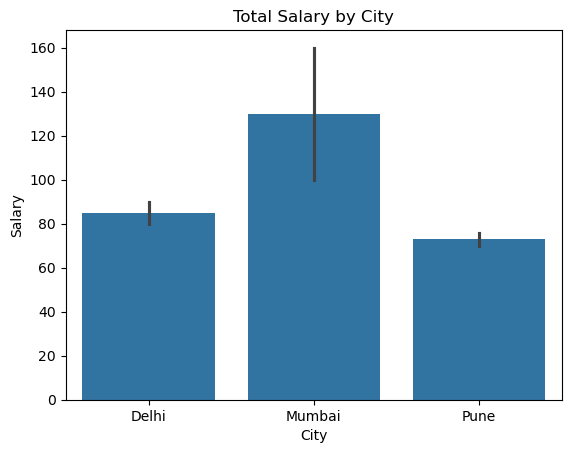

In [ ]:
sns.barplot(x="City", y="Salary", data=df, estimator=sum)
plt.title("Total Salary by City")
plt.show()

# Change Aggregation (Advanced but Useful)


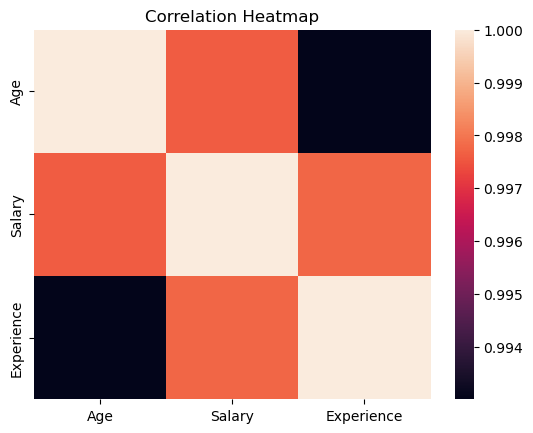

In [40]:
# Heatmap
# Correlation Heatmap (MOST IMPORTANT)
#   - Numerical features ke beech relationship

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "Age": [22, 25, 30, 35, 40],
    "Salary": [30, 40, 50, 65, 80],
    "Experience": [1, 3, 5, 8, 12]
})

corr = df.corr()

sns.heatmap(corr)
plt.title("Correlation Heatmap")
plt.show()

# How to Read Correlation Heatmap
#   - +1 (light / bright) → strong positive relation
#   - -1 (dark) → strong negative relation
#   - 0 → no relation
# Linear models ke liye high correlation = multicollinearity risk

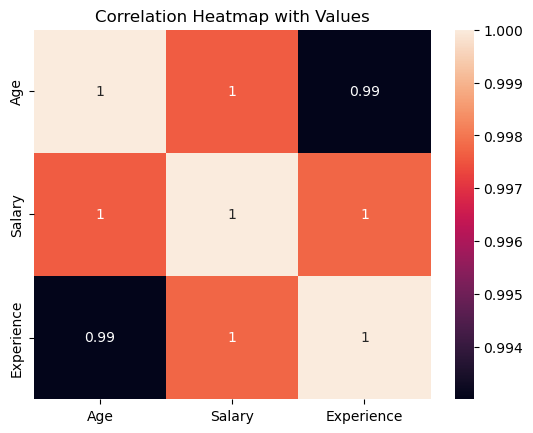

In [42]:
# Annotated Heatmap (Interview Favorite)
#   - Values clearly dikhte hain
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap with Values")
plt.show()

# Always use annot=True in interviews & reports

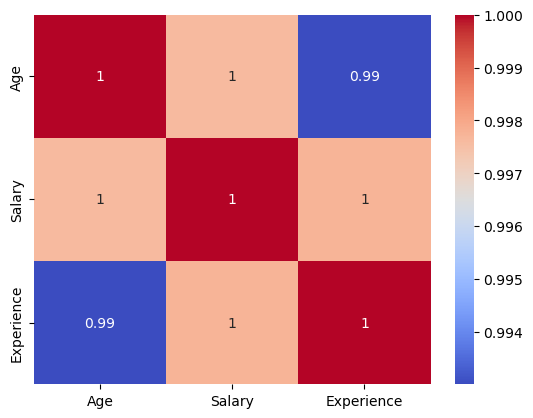

In [44]:
# Colormap Customization

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

# Common colormaps:
#   - "coolwarm" (best for correlation)
#   - "viridis"
#   - "magma"
# Color sirf clarity ke liye, decoration ke liye nahi


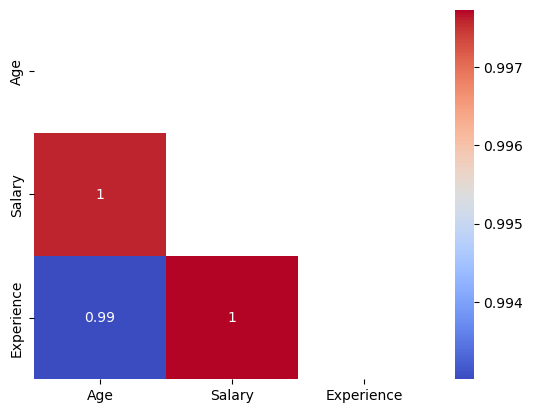

In [ ]:
# Mask Upper Triangle (Professional Look)
#   - Duplicate values hide karta hai

import numpy as np

mask = np.triu(corr)

sns.heatmap(corr, mask=mask, annot=True, cmap="coolwarm")
plt.show()

# Industry-style heatmap

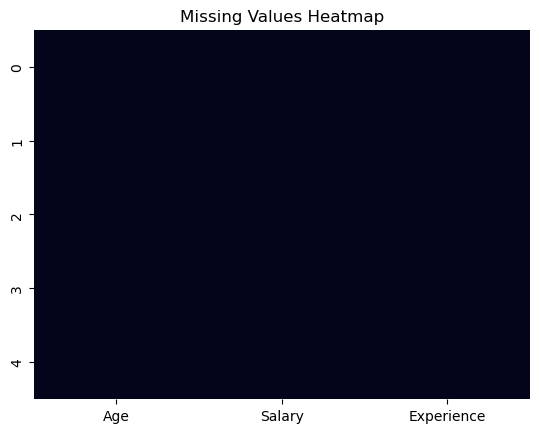

In [48]:
# Heatmap for Missing Values 
#   - Missing pattern samajhne ke liye

sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

# Quickly shows which columns have missing data


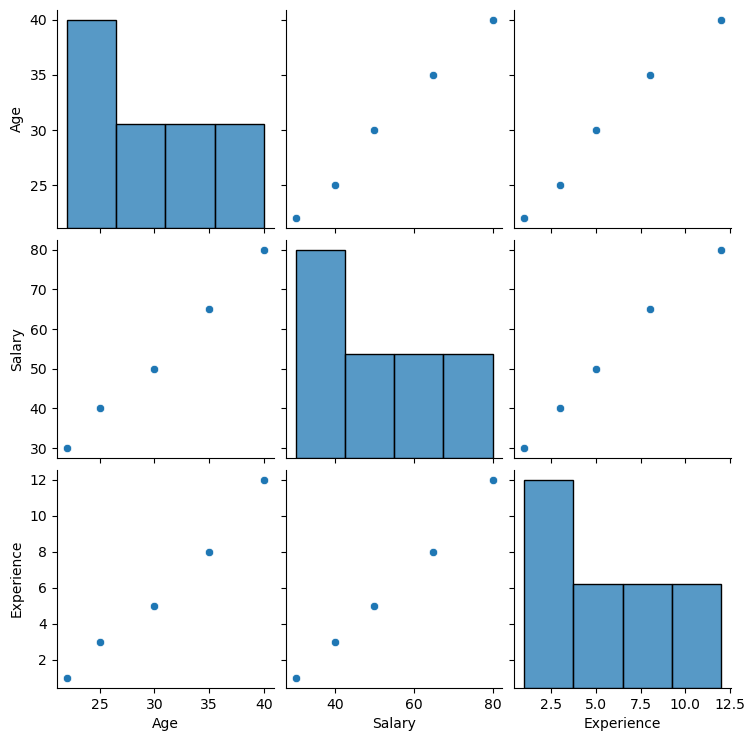

In [49]:
# Pair Plot
# Why Pair Plots are POWERFUL?
# With one command, you can see:
#   - Feature relationships (correlation)
#   - Distributions (diagonal)
#   - Outliers
#   - Class separation (with hue)

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "Age": [22, 25, 30, 35, 40],
    "Salary": [30, 40, 50, 65, 80],
    "Experience": [1, 3, 5, 8, 12]
})

sns.pairplot(df)
plt.show()

# How to Read It
# Diagonal → distribution of each feature
# Off-diagonal → relationship between two features

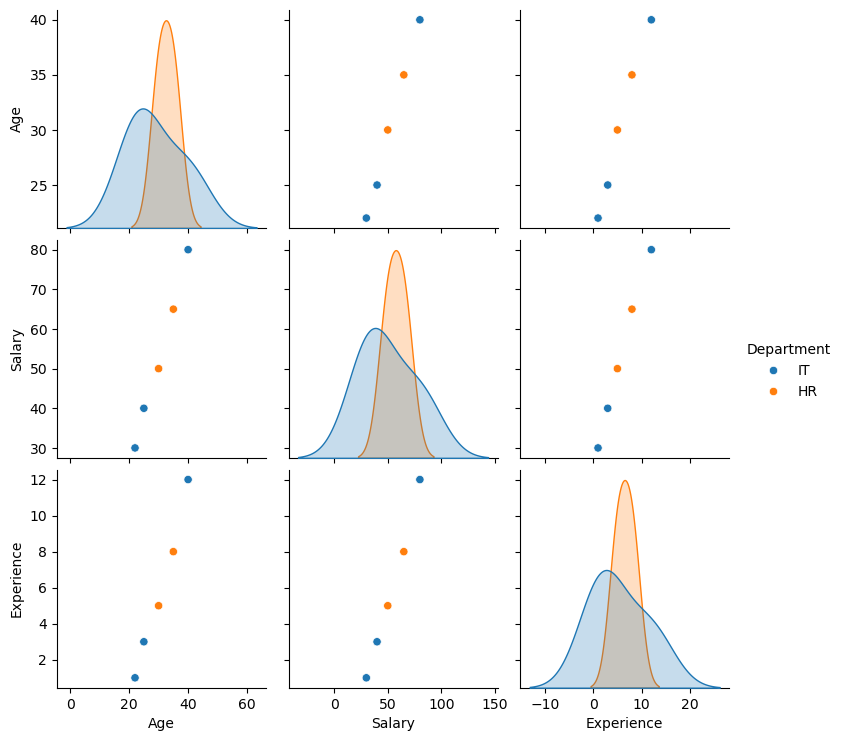

In [50]:
# Pair Plot with hue (VERY IMPORTANT )
# Category-wise separation dekhne ke liye

df["Department"] = ["IT", "IT", "HR", "HR", "IT"]

sns.pairplot(df, hue="Department")
plt.show()

# Why hue Matters
#   - Classes clearly separate ho rahi hain ya nahi
#   - ML model ke liye features useful hain ya nahi

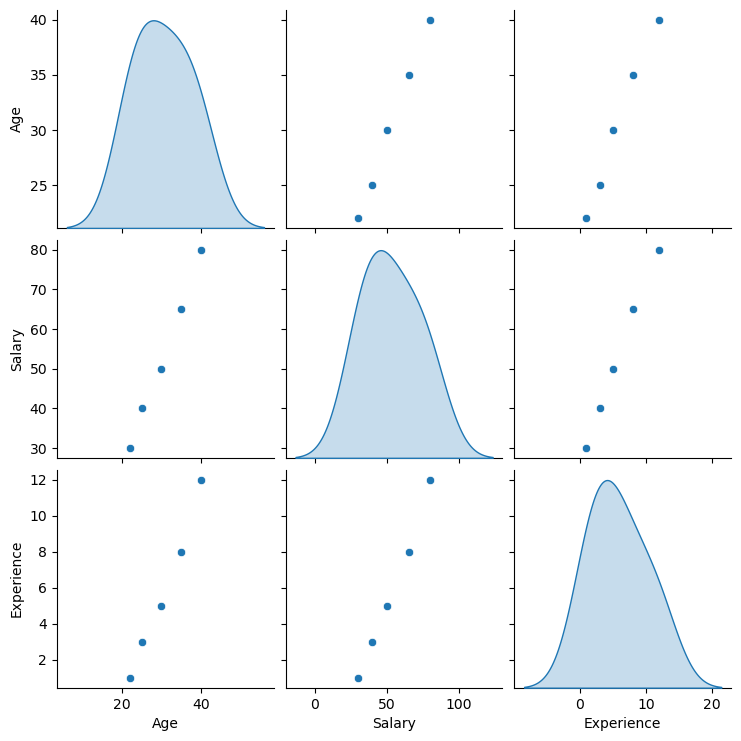

In [51]:
# Control Diagonal Plot Type
# KDE instead of histogram

sns.pairplot(df, diag_kind="kde")
plt.show()


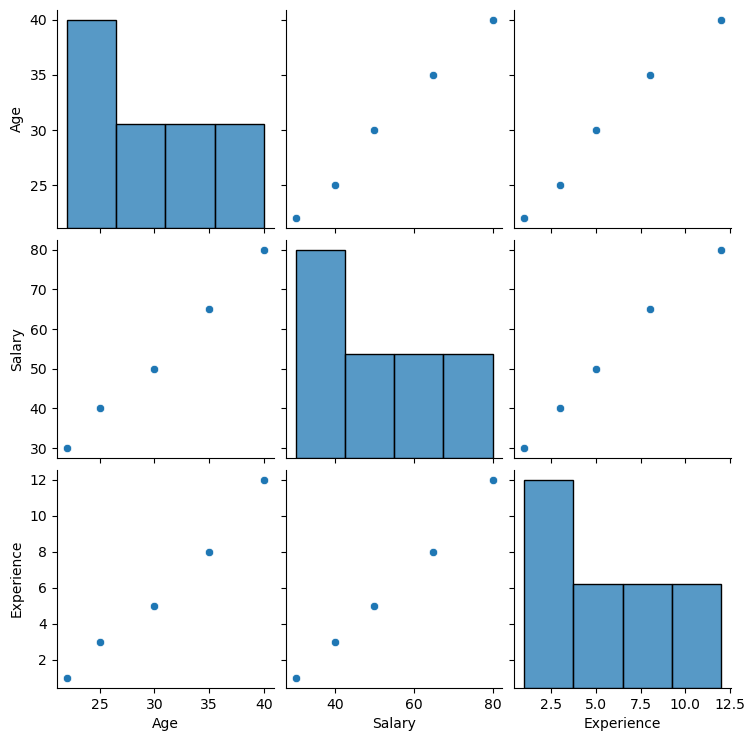

In [52]:
# Select Specific Columns (Performance Tip)

sns.pairplot(df[["Age", "Salary", "Experience"]])
plt.show()

# Large datasets me pairplot heavy hota hai

In [53]:
# Regression plots

# What are Regression Plots?
#   - Regression plots scatter + best-fit line dikhate hain.
# They help answer:
#   - Relationship linear hai ya nahi?
#   - Trend positive / negative?
#   - Outliers trend ko affect kar rahe hain?
# Rule:
#   - Relationship samajhna ho → regression plot.

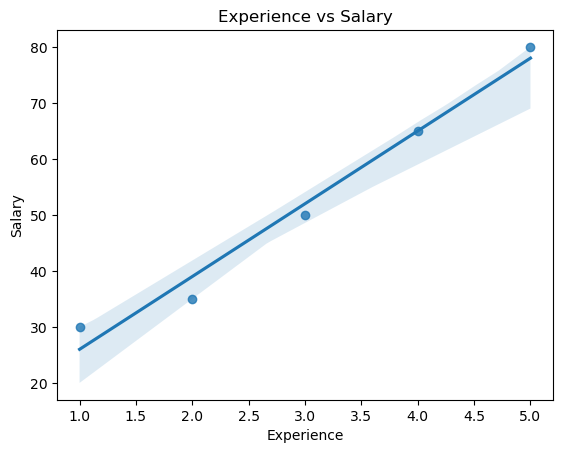

In [54]:
# regplot – Quick Relationship Check
#   - Simple, fast, most used in EDA

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = pd.DataFrame({
    "Experience": [1, 2, 3, 4, 5],
    "Salary": [30, 35, 50, 65, 80]
})

sns.regplot(x="Experience", y="Salary", data=df)
plt.title("Experience vs Salary")
plt.show()


# What regplot Tells You
#   - Linear trend present or not
#   - Strength of relationship (visually)
#   - Outliers impact
# Linear Regression decide karne se pehle MUST


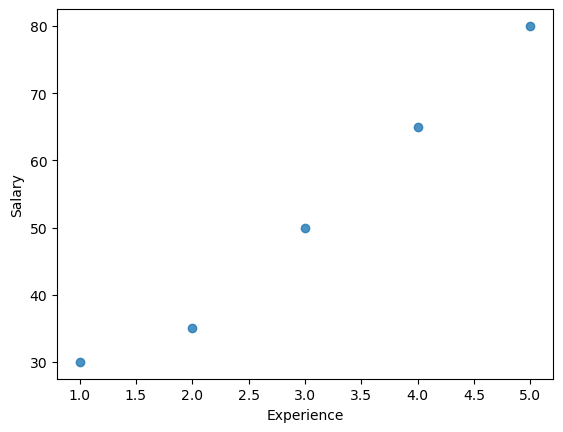

In [ ]:
# Turn OFF Regression Line (Scatter Only)
sns.regplot(x="Experience", y="Salary", data=df, fit_reg=False)
plt.show()

# regplot can behave like scatter too

c:\Users\govin\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
c:\Users\govin\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
c:\Users\govin\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
c:\Users\govin\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
c:\Users\govin\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x, _y, order), grid)
c:\Users\govin\anaconda3\Lib\site-packages\seaborn\regression.py:261: RankWarning: Polyfit may be poorly conditioned
  return np.polyval(np.polyfit(_x

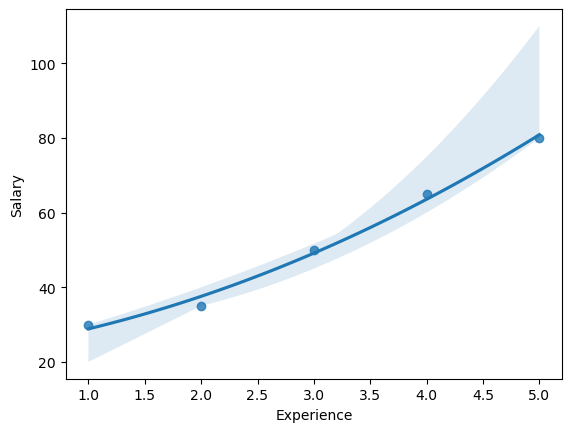

In [ ]:
# Polynomial Regression (Non-Linear Trend)

sns.regplot(x="Experience", y="Salary", data=df, order=2)
plt.show()

# Use when: curve-like relationship dikhe

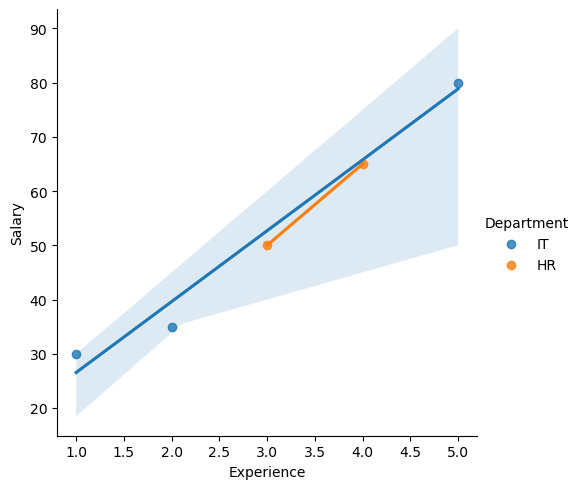

In [57]:
# lmplot – Group-wise Regression (VERY IMPORTANT )
#   - Categories ke hisaab se regression

# Example with hue

df["Department"] = ["IT", "IT", "HR", "HR", "IT"]

sns.lmplot(x="Experience", y="Salary", hue="Department", data=df)
plt.show()

# Why lmplot is Powerfut
#   - Alag-alag regression lines
#   - Class separation check
#   - Feature usefulness for classification

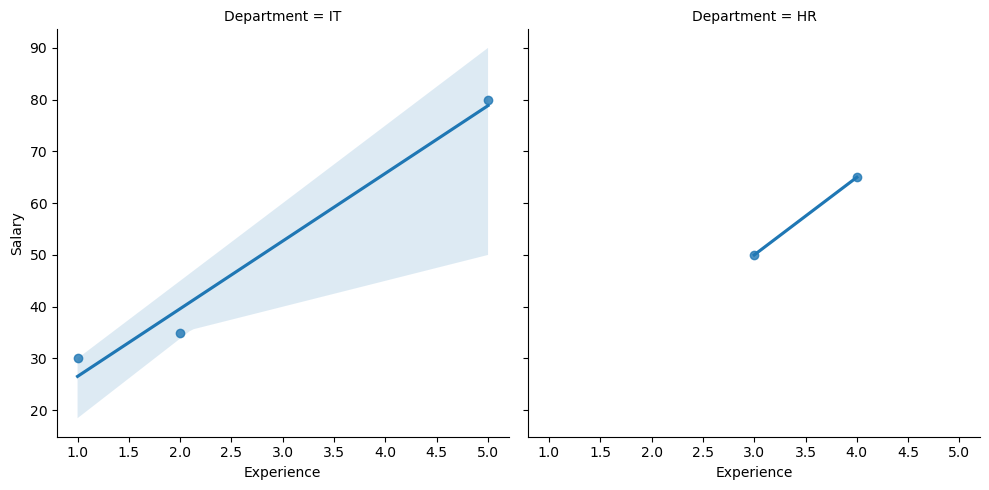

In [58]:
# mplot with Facets (Advanced View)
sns.lmplot(x="Experience", y="Salary", col="Department", data=df)
plt.show()

# Side-by-side comparison